### 5.2 데이터 분석과 전처리

데이터 불러오기와 분석하기

> kaggle competitions download -c quora-question-pairs (캐글 사이트에서 참여해야 함)

https://www.kaggle.com/c/quora-question-pairs/data

In [ ]:
import zipfile

In [ ]:
# zip 파일 압축 해제
DATA_IN_PATH = './data_in/'
file_list = ["train.csv.zip", "test.csv.zip", "sample_submission.csv.zip"]

for file in file_list:
    zipRef = zipfile.ZipFile(DATA_IN_PATH + file, 'r')
    zipRef.extractall(DATA_IN_PATH)
    zipRef.close()

In [10]:
import numpy as np 
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
train_data = pd.read_csv(DATA_IN_PATH + 'train.csv')
train_data.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [12]:
print("파일 크기 : ")
for file in os.listdir(DATA_IN_PATH):
    if 'csv' in file and 'zip' not in file:
        print(file.ljust(30) + str(round(os.path.getsize(DATA_IN_PATH + file) / 1000000, 2)) + 'MB')

파일 크기 : 
sample_submission.csv         22.35MB
test.csv                      477.59MB
train.csv                     63.4MB


In [13]:
print('전체 학습데이터의 개수: {}'.format(len(train_data)))

전체 학습데이터의 개수: 404290


1. 질문 중복 분석

In [14]:
train_set = pd.Series(train_data['question1'].tolist() + train_data['question2'].tolist()).astype(str)
train_set.head()

0    What is the step by step guide to invest in sh...
1    What is the story of Kohinoor (Koh-i-Noor) Dia...
2    How can I increase the speed of my internet co...
3    Why am I mentally very lonely? How can I solve...
4    Which one dissolve in water quikly sugar, salt...
dtype: object

In [15]:
print('교육 데이터의 총 질문 수: {}'.format(len(np.unique(train_set))))
print('반복해서 나타나는 질문의 수: {}'.format(np.sum(train_set.value_counts() > 1)))

교육 데이터의 총 질문 수: 537361
반복해서 나타나는 질문의 수: 111873


d:\anaconda3\envs\pr_tensorflow\lib\site-packages\ipykernel_launcher.py:11: MatplotlibDeprecationWarning: The 'nonposy' parameter of __init__() has been renamed 'nonpositive' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  # This is added back by InteractiveShellApp.init_path()


Text(0, 0.5, 'Number of questions')

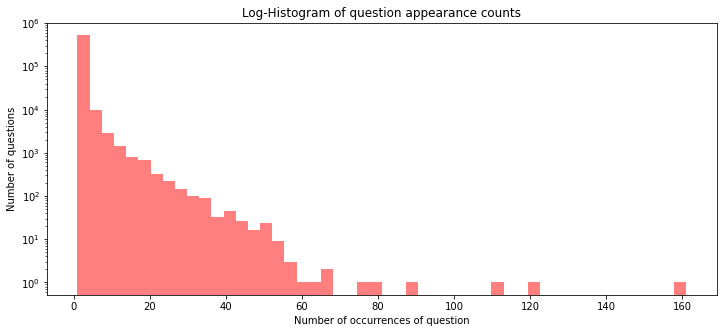

In [ ]:
# 그래프에 대한 이미지 사이즈 선언
# figsize: (가로, 세로) 형태의 튜플로 입력
plt.figure(figsize=(12, 5))
# 히스토그램 선언
# bins: 히스토그램 값들에 대한 버켓 범위
# range: x축 값의 범위
# alpha: 그래프 색상 투명도
# color: 그래프 색상
# label: 그래프에 대한 라벨
plt.hist(train_set.value_counts(), bins=50, alpha=0.5, color= 'r', label='word')
plt.yscale('log', nonposy='clip')

# 그래프 제목
plt.title('Log-Histogram of question appearance counts')

# 그래프 x 축 라벨
plt.xlabel('Number of occurrences of question')

# 그래프 y 축 라벨
plt.ylabel('Number of questions')

In [17]:
print('중복 최대 개수: {}'.format(np.max(train_set.value_counts())))
print('중복 최소 개수: {}'.format(np.min(train_set.value_counts())))
print('중복 평균 개수: {:.2f}'.format(np.mean(train_set.value_counts())))
print('중복 표준편차: {:.2f}'.format(np.std(train_set.value_counts())))
print('중복 중간길이: {}'.format(np.median(train_set.value_counts())))

# 사분위의 대한 경우는 0~100 스케일로 되어있음
print('제 1 사분위 중복: {}'.format(np.percentile(train_set.value_counts(), 25)))
print('제 3 사분위 중복: {}'.format(np.percentile(train_set.value_counts(), 75)))

중복 최대 개수: 161
중복 최소 개수: 1
중복 평균 개수: 1.50
중복 표준편차: 1.91
중복 중간길이: 1.0
제 1 사분위 중복: 1.0
제 3 사분위 중복: 1.0


{'whiskers': [<matplotlib.lines.Line2D at 0x26165a8d668>,
 'caps': [<matplotlib.lines.Line2D at 0x26165a8dc18>,
 'boxes': [<matplotlib.lines.Line2D at 0x26165a8d400>],
 'medians': [<matplotlib.lines.Line2D at 0x26165a9a208>],
 'fliers': [<matplotlib.lines.Line2D at 0x26165a9a6d8>],
 'means': [<matplotlib.lines.Line2D at 0x26165a9a4e0>]}

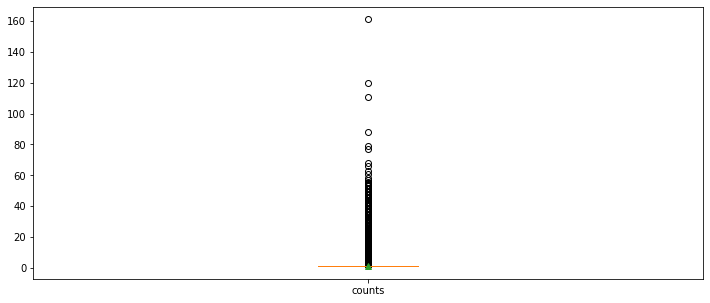

In [ ]:
# 중복 질문 횟수 박스플롯
plt.figure(figsize=(12, 5))
# 박스플롯 생성
# 첫번째 파라메터: 여러 분포에 대한 데이터 리스트를 입력
# labels: 입력한 데이터에 대한 라벨
# showmeans: 평균값을 마크함

plt.boxplot([train_set.value_counts()],
            labels=['counts'],
            showmeans=True)

(-0.5, 799.5, 599.5, -0.5)

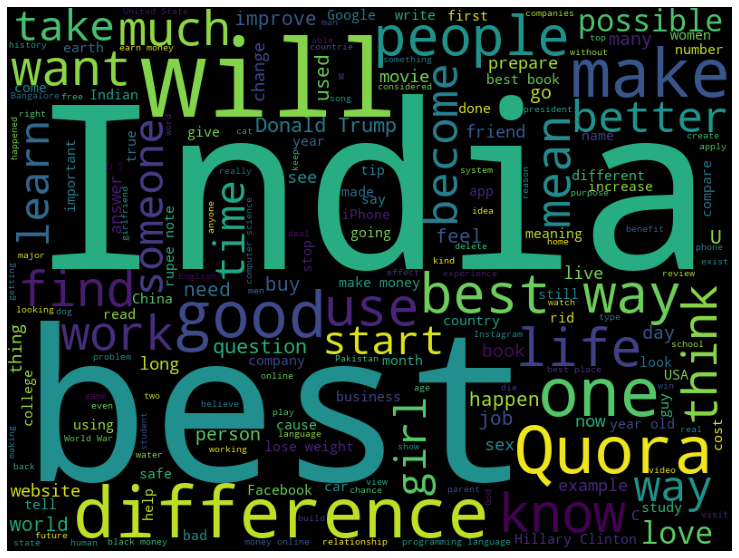

In [19]:
from wordcloud import WordCloud
cloud = WordCloud(width=800, height=600).generate(" ".join(train_set.astype(str)))

plt.figure(figsize=(15, 10))
plt.imshow(cloud)
plt.axis('off')

2. 라벨 빈도 분석

d:\anaconda3\envs\pr_tensorflow\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='is_duplicate', ylabel='count'>

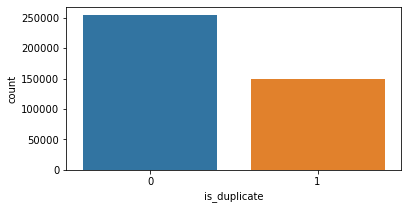

In [ ]:
fig, axe = plt.subplots(ncols=1)
fig.set_size_inches(6, 3)
sns.countplot(train_data['is_duplicate'])

# 중복 질문 수: 약 150,000개
# 고유 질문 수: 약 250,000개

3. 텍스트 길이 분석 (문자 단위)

In [24]:
train_length = train_set.apply(len)
print(train_length)

0          66
1          51
2          73
3          50
4          76
         ... 
808575     79
808576     42
808577     17
808578    127
808579     45
Length: 808580, dtype: int64


Text(0, 0.5, 'Probability')

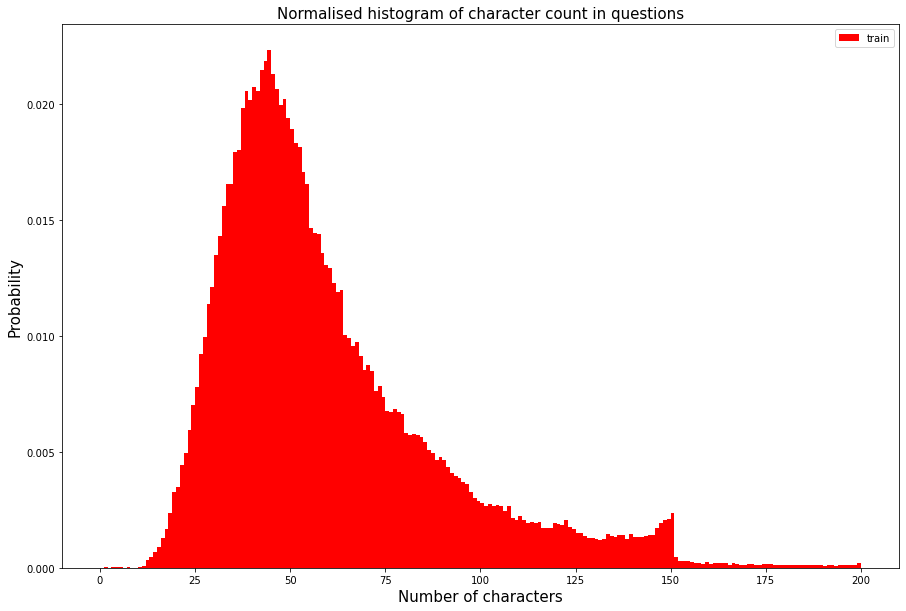

In [ ]:
# 각 데이터의 길이값 히스토그램
plt.figure(figsize=(15, 10))
plt.hist(train_length, bins=200, range=[0,200], facecolor='r', density=True, label='train')
plt.title("Normalised histogram of character count in questions", fontsize=15)
plt.legend()
plt.xlabel('Number of characters', fontsize=15)
plt.ylabel('Probability', fontsize=15)

In [23]:
print('질문 길이 최대 값: {}'.format(np.max(train_length)))
print('질문 길이 평균 값: {:.2f}'.format(np.mean(train_length)))
print('질문 길이 표준편차: {:.2f}'.format(np.std(train_length)))
print('질문 길이 중간 값: {}'.format(np.median(train_length)))
print('질문 길이 제 1 사분위: {}'.format(np.percentile(train_length, 25)))
print('질문 길이 제 3 사분위: {}'.format(np.percentile(train_length, 75)))

질문 길이 최대 값: 1169
질문 길이 평균 값: 59.82
질문 길이 표준편차: 31.96
질문 길이 중간 값: 51.0
질문 길이 제 1 사분위: 39.0
질문 길이 제 3 사분위: 72.0


{'whiskers': [<matplotlib.lines.Line2D at 0x26165b7bb70>,
 'caps': [<matplotlib.lines.Line2D at 0x26165b900b8>,
 'boxes': [<matplotlib.lines.Line2D at 0x26165b7b908>],
 'medians': [<matplotlib.lines.Line2D at 0x26165b906d8>],
 'fliers': [<matplotlib.lines.Line2D at 0x26165b90c88>],
 'means': [<matplotlib.lines.Line2D at 0x26165b90a20>]}

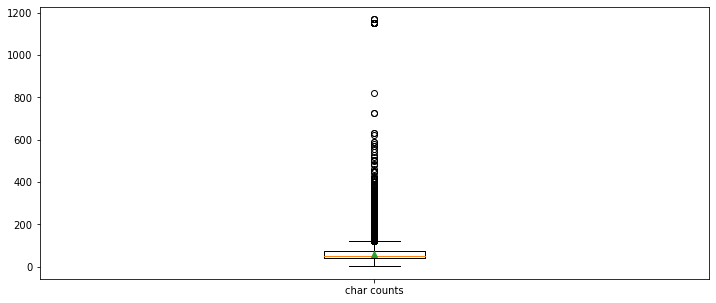

In [25]:
# 질문 길이값 박스플롯
plt.figure(figsize=(12, 5))

plt.boxplot(train_length,
            labels=['char counts'],
            showmeans=True)

4. 텍스트 길이 분석 (단어 단위)

Text(0, 0.5, 'Prabability')

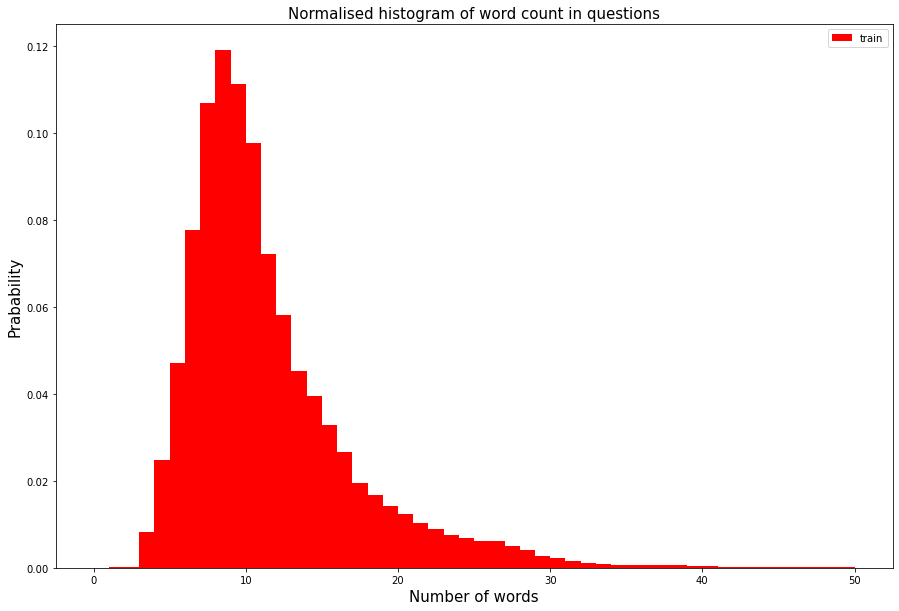

In [26]:
# 단어 개수로 길이값 분석
train_word_counts = train_set.apply(lambda x:len(x.split(' ')))

plt.figure(figsize=(15, 10))
plt.hist(train_word_counts, bins=50, range=[0, 50], facecolor='r', density=True, label='train')
plt.title('Normalised histogram of word count in questions', fontsize=15)
plt.legend()
plt.xlabel('Number of words', fontsize=15)
plt.ylabel('Prabability', fontsize=15)

In [27]:
print('질문 단어 개수 최대 값: {}'.format(np.max(train_word_counts)))
print('질문 단어 개수 평균 값: {:.2f}'.format(np.mean(train_word_counts)))
print('질문 단어 개수 표준편차: {:.2f}'.format(np.std(train_word_counts)))
print('질문 단어 개수 중간 값: {}'.format(np.median(train_word_counts)))
print('질문 단어 개수 제 1 사분위: {}'.format(np.percentile(train_word_counts, 25)))
print('질문 단어 개수 제 3 사분위: {}'.format(np.percentile(train_word_counts, 75)))
print('질문 단어 개수 99 퍼센트: {}'.format(np.percentile(train_word_counts, 99)))

질문 단어 개수 최대 값: 237
질문 단어 개수 평균 값: 11.06
질문 단어 개수 표준편차: 5.89
질문 단어 개수 중간 값: 10.0
질문 단어 개수 제 1 사분위: 7.0
질문 단어 개수 제 3 사분위: 13.0
질문 단어 개수 99 퍼센트: 31.0


{'whiskers': [<matplotlib.lines.Line2D at 0x2617a496550>,
 'caps': [<matplotlib.lines.Line2D at 0x2617a496b00>,
 'boxes': [<matplotlib.lines.Line2D at 0x2617a4962e8>],
 'medians': [<matplotlib.lines.Line2D at 0x2617a48d128>],
 'fliers': [<matplotlib.lines.Line2D at 0x2617a48d5f8>],
 'means': [<matplotlib.lines.Line2D at 0x2617a48d400>]}

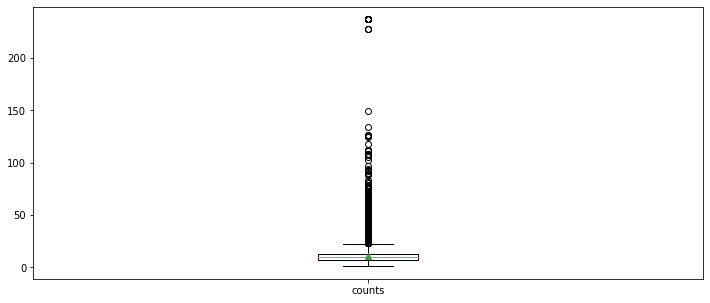

In [28]:
plt.figure(figsize=(12, 5))

plt.boxplot(train_word_counts,
            labels=['counts'],
            showmeans=True)

In [29]:
qmarks = np.mean(train_set.apply(lambda x: '?' in x)) # 물음표가 구두점으로 쓰임
math = np.mean(train_set.apply(lambda x: '[math]' in x)) # []
fullstop = np.mean(train_set.apply(lambda x: '.' in x)) # 마침표
capital_first = np.mean(train_set.apply(lambda x: x[0].isupper())) #  첫번째 대문자
capitals = np.mean(train_set.apply(lambda x: max([y.isupper() for y in x]))) # 대문자가 몇개
numbers = np.mean(train_set.apply(lambda x: max([y.isdigit() for y in x]))) # 숫자가 몇개

print('물음표가있는 질문: {:.2f}%'.format(qmarks * 100))
print('수학 태그가있는 질문: {:.2f}%'.format(math * 100))
print('마침표를 포함한 질문: {:.2f}%'.format(fullstop * 100))
print('첫 글자가 대문자 인 질문: {:.2f}%'.format(capital_first * 100))
print('대문자가있는 질문: {:.2f}%'.format(capitals * 100))
print('숫자가있는 질문: {:.2f}%'.format(numbers * 100))

물음표가있는 질문: 99.87%
수학 태그가있는 질문: 0.12%
마침표를 포함한 질문: 6.31%
첫 글자가 대문자 인 질문: 99.81%
대문자가있는 질문: 99.95%
숫자가있는 질문: 11.83%


데이터 전처리

In [30]:
import pandas as pd
import numpy as np
import re
import json

from tensorflow.python.keras.preprocessing.text import Tokenizer
from tensorflow.python.keras.preprocessing.sequence import pad_sequences

In [ ]:
DATA_IN_PATH = './data_in/'

train_data = pd.read_csv(DATA_IN_PATH + 'train.csv', encoding='utf-8')
train_data.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [32]:
# 라벨 개수 균형 맞추기
train_pos_data = train_data.loc[train_data['is_duplicate'] == 1]
train_neg_data = train_data.loc[train_data['is_duplicate'] == 0]

class_difference = len(train_neg_data) - len(train_pos_data)
sample_frac = 1 - (class_difference / len(train_neg_data))

train_neg_data = train_neg_data.sample(frac = sample_frac)

print("중복 질문 개수: {}".format(len(train_pos_data)))
print("중복이 아닌 질문 개수: {}".format(len(train_neg_data)))

중복 질문 개수: 149263
중복이 아닌 질문 개수: 149263


In [33]:
# 데이터 합치기
train_data = pd.concat([train_pos_data, train_neg_data])
train_data.head()

,id,qid1,qid2,question1,question2,is_duplicate
5,5,11,12,Astrology: I am a Capricorn Sun Cap moon and c...,"I'm a triple Capricorn (Sun, Moon and ascendan...",1
7,7,15,16,How can I be a good geologist?,What should I do to be a great geologist?,1
11,11,23,24,How do I read and find my YouTube comments?,How can I see all my Youtube comments?,1
12,12,25,26,What can make Physics easy to learn?,How can you make physics easy to learn?,1
13,13,27,28,What was your first sexual experience like?,What was your first sexual experience?,1


In [ ]:
# 텍스트 전처리
FILTERS = "([~.,!?\"':;)(])"
change_filter = re.compile(FILTERS)

questions1 = [str(s) for s in train_data['question1']]
questions2 = [str(s) for s in train_data['question2']]

filtered_questions1 = list()
filtered_questions2 = list()

for q in questions1:
    filtered_questions1.append(re.sub(change_filter, "", q).lower())
        
for q in questions2:
    filtered_questions2.append(re.sub(change_filter, "", q).lower())

In [35]:
# 토크나이징 객체 생성
tokenizer = Tokenizer()
tokenizer.fit_on_texts(filtered_questions1 + filtered_questions2) 

# 각 질문에 대해 토크나이징을 따로 진행
questions1_sequence = tokenizer.texts_to_sequences(filtered_questions1)
questions2_sequence = tokenizer.texts_to_sequences(filtered_questions2)

# 패딩: 최대 길이 지정 후 긴 질문은 자르고, 짧은 질문은 0으로 채움
MAX_SEQUENCE_LENGTH = 31  # 질문 단어 개수 99 퍼센트

q1_data = pad_sequences(questions1_sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
q2_data = pad_sequences(questions2_sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

In [36]:
word_vocab = {}
word_vocab = tokenizer.word_index 
word_vocab["<PAD>"] = 0

labels = np.array(train_data['is_duplicate'], dtype=int)

print('Shape of question1 data: {}'.format(q1_data.shape))
print('Shape of question2 data:{}'.format(q2_data.shape))
print('Shape of label: {}'.format(labels.shape))
print("Words in index: {}".format(len(word_vocab)))

Shape of question1 data: (298526, 31)
Shape of question2 data:(298526, 31)
Shape of label: (298526,)
Words in index: 76251


In [37]:
print(word_vocab)

{'the': 1, 'what': 2, 'is': 3, 'how': 4, 'i': 5, 'to': 6, 'a': 7, 'in': 8, 'do': 9, 'of': 10, 'are': 11, 'and': 12, 'can': 13, 'for': 14, 'you': 15, 'why': 16, 'best': 17, 'my': 18, 'it': 19, 'on': 20, 'does': 21, 'which': 22, 'be': 23, 'if': 24, 'some': 25, 'or': 26, 'get': 27, 'have': 28, 'that': 29, 'should': 30, 'with': 31, 'your': 32, 'an': 33, 'from': 34, 'india': 35, 'will': 36, 'people': 37, 'who': 38, 'when': 39, 'like': 40, 'good': 41, 'would': 42, 'at': 43, 'there': 44, 'as': 45, 'about': 46, 'quora': 47, 'between': 48, 'most': 49, 'one': 50, 'not': 51, 'way': 52, 'make': 53, 'we': 54, 'did': 55, 'life': 56, 'by': 57, 'where': 58, 'money': 59, 'was': 60, 'any': 61, 'so': 62, 'time': 63, 'me': 64, 'after': 65, 'learn': 66, 'know': 67, 'they': 68, 'this': 69, 'difference': 70, 'whats': 71, 'has': 72, 'new': 73, 'think': 74, 'trump': 75, 'much': 76, 'ever': 77, 'use': 78, 'indian': 79, 'am': 80, 'all': 81, 'many': 82, 'their': 83, 'work': 84, 'us': 85, 'become': 86, 'someone': 

In [38]:
data_configs = {}
data_configs['vocab'] = word_vocab
data_configs['vocab_size'] = len(word_vocab)

print(data_configs)

{'vocab': {'the': 1, 'what': 2, 'is': 3, 'how': 4, 'i': 5, 'to': 6, 'a': 7, 'in': 8, 'do': 9, 'of': 10, 'are': 11, 'and': 12, 'can': 13, 'for': 14, 'you': 15, 'why': 16, 'best': 17, 'my': 18, 'it': 19, 'on': 20, 'does': 21, 'which': 22, 'be': 23, 'if': 24, 'some': 25, 'or': 26, 'get': 27, 'have': 28, 'that': 29, 'should': 30, 'with': 31, 'your': 32, 'an': 33, 'from': 34, 'india': 35, 'will': 36, 'people': 37, 'who': 38, 'when': 39, 'like': 40, 'good': 41, 'would': 42, 'at': 43, 'there': 44, 'as': 45, 'about': 46, 'quora': 47, 'between': 48, 'most': 49, 'one': 50, 'not': 51, 'way': 52, 'make': 53, 'we': 54, 'did': 55, 'life': 56, 'by': 57, 'where': 58, 'money': 59, 'was': 60, 'any': 61, 'so': 62, 'time': 63, 'me': 64, 'after': 65, 'learn': 66, 'know': 67, 'they': 68, 'this': 69, 'difference': 70, 'whats': 71, 'has': 72, 'new': 73, 'think': 74, 'trump': 75, 'much': 76, 'ever': 77, 'use': 78, 'indian': 79, 'am': 80, 'all': 81, 'many': 82, 'their': 83, 'work': 84, 'us': 85, 'become': 86, '

In [39]:
TRAIN_Q1_DATA = 'train_q1.npy'
TRAIN_Q2_DATA = 'train_q2.npy'
TRAIN_LABEL_DATA = 'train_label.npy'
DATA_CONFIGS = 'data_configs.json'

np.save(open(DATA_IN_PATH + TRAIN_Q1_DATA, 'wb'), q1_data)
np.save(open(DATA_IN_PATH + TRAIN_Q2_DATA , 'wb'), q2_data)
np.save(open(DATA_IN_PATH + TRAIN_LABEL_DATA , 'wb'), labels)

json.dump(data_configs, open(DATA_IN_PATH + DATA_CONFIGS, 'w'))

In [40]:
test_data = pd.read_csv(DATA_IN_PATH + 'test.csv', encoding='utf-8')
# test_data = test_data.drop(test_data.tail(1217679).index,inplace=True) # drop last n rows

valid_ids = [type(x) ==int for x in test_data.test_id] 
test_data = test_data[valid_ids].drop_duplicates()

d:\anaconda3\envs\pr_tensorflow\lib\site-packages\IPython\core\interactiveshell.py:3072: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [41]:
# 평가 데이터 전처리
test_questions1 = [str(s) for s in test_data['question1']]
test_questions2 = [str(s) for s in test_data['question2']]

filtered_test_questions1 = list()
filtered_test_questions2 = list()

for q in test_questions1:
    filtered_test_questions1.append(re.sub(change_filter, "", q).lower())
        
for q in test_questions2:
    filtered_test_questions2.append(re.sub(change_filter, "", q).lower())

In [42]:
# 이전에 학습한 토크나이저로 텍스트 시퀀스 생성
test_questions1_sequence = tokenizer.texts_to_sequences(filtered_test_questions1)
test_questions2_sequence = tokenizer.texts_to_sequences(filtered_test_questions2)

test_q1_data = pad_sequences(test_questions1_sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
test_q2_data = pad_sequences(test_questions2_sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

test_id = np.array(test_data['test_id'])

print('Shape of question1 data: {}'.format(test_q1_data.shape))
print('Shape of question2 data:{}'.format(test_q2_data.shape))
print('Shape of ids: {}'.format(test_id.shape))

Shape of question1 data: (2345796, 31)
Shape of question2 data:(2345796, 31)
Shape of ids: (2345796,)


In [43]:
TEST_Q1_DATA = 'test_q1.npy'
TEST_Q2_DATA = 'test_q2.npy'
TEST_ID_DATA = 'test_id.npy'

np.save(open(DATA_IN_PATH + TEST_Q1_DATA, 'wb'), test_q1_data)
np.save(open(DATA_IN_PATH + TEST_Q2_DATA , 'wb'), test_q2_data)
np.save(open(DATA_IN_PATH + TEST_ID_DATA , 'wb'), test_id)